In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits

from mock_config import CONFIG, FP_CLUS

cosmo = FlatLambdaCDM(H0=100., Om0=0.3151)

In [2]:
d_data = fits.open(CONFIG.data_fp_clus_data)[1].data
d_rand = fits.open(CONFIG.data_fp_clus_rand)[1].data
d_data.names, d_rand.names, d_data.size, d_rand.size

(['TARGETID',
  'RA',
  'DEC',
  'Z',
  'ZCMB',
  'WEIGHT',
  'NPV',
  'NDENS',
  'LOGDIST',
  'LOGDIST_ERR'],
 ['RA',
  'DEC',
  'Z',
  'ZCMB',
  'WEIGHT',
  'NPV',
  'NDENS',
  'MU_ERR',
  'LOGDIST_ERR',
  'PV_ERR'],
 159187,
 3183740)

In [16]:
m_data = fits.open(CONFIG.mock_fp_clus_data.format(phase=0, real=0))[1].data
m_rand = fits.open(CONFIG.mock_fp_clus_rand)[1].data
print(m_data.names,m_data.size)
print(m_rand.names, m_rand.size)
print(m_data['WEIGHT'])

['RA', 'DEC', 'Z', 'WEIGHT', 'NPV', 'NDENS', 'LOGDIST', 'LOGDIST_ERR', 'LOGDIST_TRUE', 'PV', 'PV_ERR', 'PV_TRUE'] 149998
['RA', 'DEC', 'Z', 'WEIGHT', 'NPV', 'NDENS', 'LOGDIST_ERR', 'PV_ERR'] 2999460
[1. 1. 1. ... 1. 1. 1.]


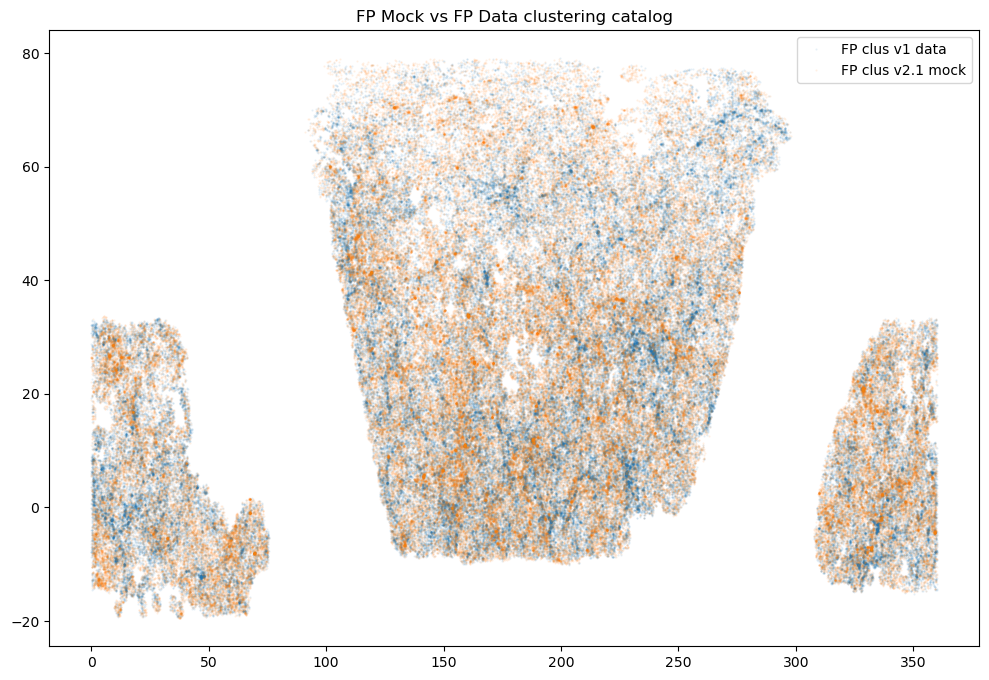

In [7]:
plt.figure(figsize=(12, 8))
plt.plot(d_data['RA'], d_data['DEC'], '.', ms=1, alpha=0.1, label=f'FP clus {CONFIG.data_fp_full_version} data')
plt.plot(m_data['RA'], m_data['DEC'], '.', ms=1, alpha=0.1, label=f'FP clus {CONFIG.version_fp_full} mock')
plt.title('FP Mock vs FP Data clustering catalog')
plt.legend()

Text(0, 0.5, 'Dec [deg]')

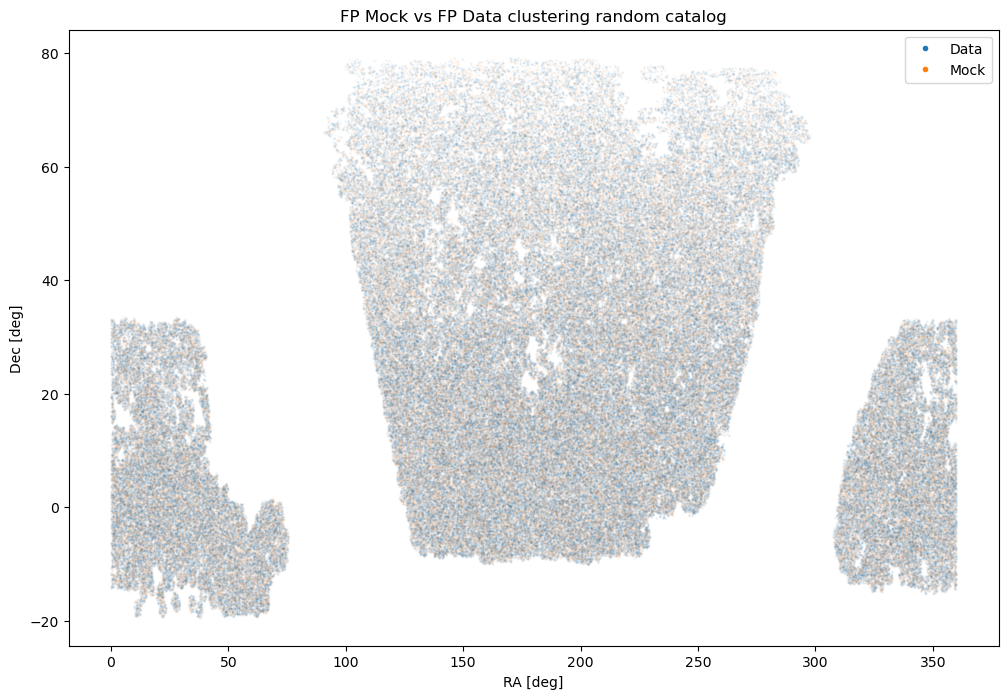

In [8]:
plt.figure(figsize=(12, 8))
plt.plot(d_rand['RA'][::20], d_rand['DEC'][::20], '.', ms=1, alpha=0.1)
plt.plot(m_rand['RA'][::20], m_rand['DEC'][::20], '.', ms=0.5, alpha=0.1)
plt.plot([], [], 'C0.', label='Data')
plt.plot([], [], 'C1.', label='Mock')
plt.title('FP Mock vs FP Data clustering random catalog')
plt.legend()
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]') 

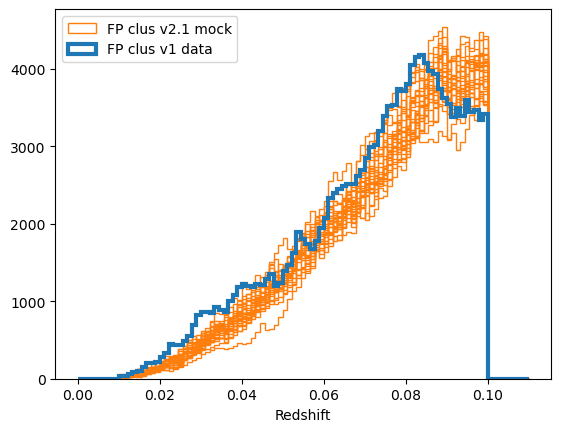

In [5]:
zbins = np.linspace(0, 0.11, 100)
for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(CONFIG.mock_fp_clus_data.format(phase=phase, real=real))[1].data
        label = f'FP clus {CONFIG.version_fp_full} mock' if phase == 0 and real ==0 else None 
        _=plt.hist(m_data_temp['Z'], color='C1', bins=zbins, histtype='step', alpha=1, label=label)

_=plt.hist(d_data['Z'], bins=zbins, histtype='step', lw=3,
           label=f'FP clus {CONFIG.data_fp_full_version} data')

plt.xlabel('Redshift')
plt.legend()

In [6]:
area_ngc = 8500.3589 # sq deg
area_sgc = 3610.6785 # sq deg

area_tot = area_ngc + area_sgc # sq deg

zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=41253.):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz/zvol/area


In [7]:
m_nzs = []
for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(CONFIG.mock_fp_clus_data.format(phase=phase, real=real))[1].data
        m_nz = get_nz(m_data_temp['Z'], area=area_tot)
        m_nzs.append(m_nz)
m_nzs = np.array(m_nzs) 
print(m_nzs.shape)

(27, 99)


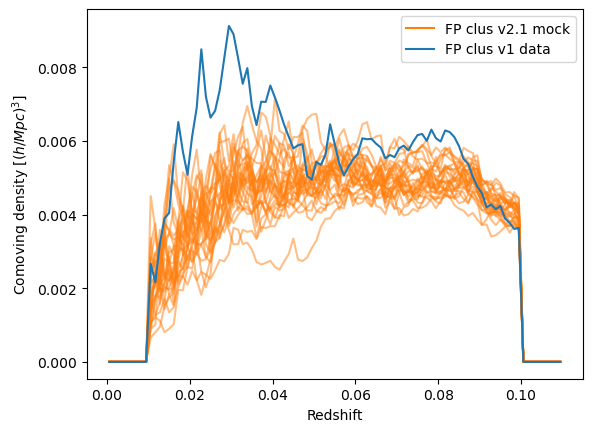

In [8]:
for m_nz in m_nzs:      
    plt.plot(zcen, m_nz, 'C1-', alpha=0.5)
plt.plot([], [], 'C1-', label=f'FP clus {CONFIG.version_fp_full} mock')

d_nz = get_nz(d_data['Z'], weights=d_data['WEIGHT'], area=area_tot)
plt.plot(zcen, d_nz, 'C0-', label=f'FP clus {CONFIG.data_fp_full_version} data')

plt.ylabel('Comoving density [${(h/Mpc)}^3$]')
plt.xlabel('Redshift')
plt.legend()
plt.savefig(f'plots/FP_clus_nz_mock_{CONFIG.version_fp_clus}_data_{CONFIG.data_fp_full_version}.pdf')

In [9]:
from mock_fp_clustering_claude import *

In [11]:
FP_CLUS.phase = 0 
bgs_rand, fp_data = load_observed_data()

nz_fp_data = np.histogram(
        fp_data["Z"], bins=FP_CLUS.nzbin, range=[FP_CLUS.zmin, FP_CLUS.zmax],
        weights=fp_data["WEIGHT"],
    )[0]

# 2. Accumulate mock statistics
stats = accumulate_mock_statistics()

#for k in stats.keys():
#    log.info(f"  {k}: {stats[k]} {stats[k].size} {np.isnan(stats[k]).sum()}")

# 3. Sub-sampling fraction & logdist bias correction
subfrac     = compute_subsampling_fraction(nz_fp_data, stats["nz_fp_mock"])


02:07:56  INFO      Loading observed data …
02:07:59  INFO      Accumulating mock statistics …
02:07:59  INFO        Phase 0 …
02:08:04  INFO      Mocks processed: 27 BGS / 27 FP | pull: mean=0.0005, std=0.9911
02:08:04  INFO      Sub-sampling fraction: min=0.873, max=1.000


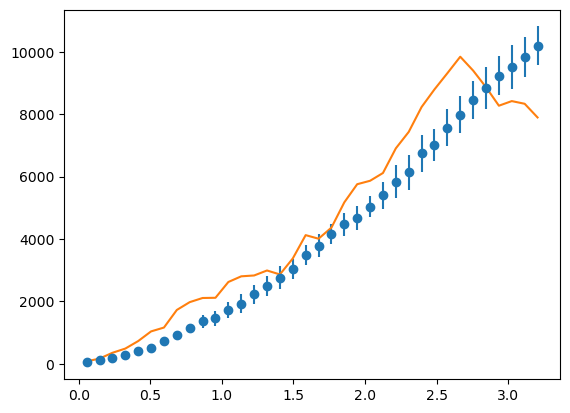

In [25]:
zcen = (np.arange(FP_CLUS.nzbin)+0.5)*(FP_CLUS.zmax - FP_CLUS.zmin) + FP_CLUS.zmin

plt.errorbar(zcen, stats['nz_fp_mock'], stats['nz_fp_mock_err'], fmt='o')
plt.plot(zcen, nz_fp_data)
